In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import dist

In [24]:
df_rds = pd.read_csv("../data/raw/_roads.tsv", sep = "\t", low_memory=False)
df_rds.describe()

,lat1,lon1,lat2,lon2,Unnamed: 8,Unnamed: 9,Unnamed: 11,Unnamed: 12,Unnamed: 14,Unnamed: 15,...,Unnamed: 4031,Unnamed: 4032,Unnamed: 4034,Unnamed: 4035,Unnamed: 4037,Unnamed: 4038,Unnamed: 4040,Unnamed: 4041,Unnamed: 4043,Unnamed: 4044
count,877.000000,877.000000,876.000000,876.000000,868.000000,868.000000,852.000000,852.000000,843.000000,843.000000,...,1.00000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
mean,23.824894,90.250037,23.830107,90.251002,23.829570,90.252170,23.839467,90.245770,23.835393,90.243829,...,20.86886,92.298222,20.865028,92.29825,20.864667,92.298194,20.862972,92.298083,20.862917,92.298083
std,1.079927,1.035133,1.081952,1.037238,1.085892,1.035562,1.096923,1.031690,1.090617,1.035085,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,20.862861,88.163583,20.857750,88.076610,20.855333,88.156806,20.847250,88.155139,20.846500,88.155750,...,20.86886,92.298222,20.865028,92.29825,20.864667,92.298194,20.862972,92.298083,20.862917,92.298083
25%,22.989555,89.383694,22.990784,89.390402,22.990118,89.389812,23.009111,89.396437,23.005667,89.387250,...,20.86886,92.298222,20.865028,92.29825,20.864667,92.298194,20.862972,92.298083,20.862917,92.298083
50%,23.785611,90.216083,23.788889,90.214903,23.787944,90.207403,23.791194,90.197291,23.790000,90.197333,...,20.86886,92.298222,20.865028,92.29825,20.864667,92.298194,20.862972,92.298083,20.862917,92.298083
75%,24.613417,90.986944,24.664750,90.991798,24.668701,90.994930,24.671999,90.987152,24.652514,90.987750,...,20.86886,92.298222,20.865028,92.29825,20.864667,92.298194,20.862972,92.298083,20.862917,92.298083
max,26.488889,92.875666,26.488777,92.730472,26.488750,92.387416,27.786139,92.301250,26.488194,92.300917,...,20.86886,92.298222,20.865028,92.29825,20.864667,92.298194,20.862972,92.298083,20.862917,92.298083


In [25]:
df_rds.head()

,road,lrp1,lat1,lon1,lrp2,lat2,lon2,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 4035,Unnamed: 4036,Unnamed: 4037,Unnamed: 4038,Unnamed: 4039,Unnamed: 4040,Unnamed: 4041,Unnamed: 4042,Unnamed: 4043,Unnamed: 4044
0,N1,LRPS,23.706028,90.443333,LRPSa,23.702917,90.450417,LRPSb,23.702778,90.450472,...,92.29825,LRP466c,20.864667,92.298194,LRP467,20.862972,92.298083,LRPE,20.862917,92.298083
1,N101,LRPS,23.454139,91.212861,LRPSa,23.461889,91.212000,LRP001,23.462944,91.211806,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N102,LRPS,23.478972,91.118194,LRPSa,23.481583,91.116777,LRPSb,23.486666,91.113361,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N103,LRPS,23.957028,91.115528,LRP001,23.961917,91.113611,LRP001a,23.967666,91.111889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N104,LRPS,23.009667,91.399416,LRPSa,23.009278,91.395250,LRP001,23.009306,91.389805,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
df_rds.tail()

,road,lrp1,lat1,lon1,lrp2,lat2,lon2,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 4035,Unnamed: 4036,Unnamed: 4037,Unnamed: 4038,Unnamed: 4039,Unnamed: 4040,Unnamed: 4041,Unnamed: 4042,Unnamed: 4043,Unnamed: 4044
880,Z8910,LRPS,22.674722,90.408889,LRPSa,22.675916,90.412556,LRP001,22.675583,90.417166,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
881,Z8913,LRPS,22.396083,90.688666,LRPSa,22.393027,90.688944,LRPSb,22.392666,90.689083,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
882,Z8915,LRPS,22.589389,90.619472,LRP001,22.589694,90.623360,LRP001a,22.590027,90.631360,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
883,Z8916,LRPS,22.625499,90.661722,LRPSa,22.623888,90.664167,LRP001,22.620305,90.668999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
884,Z8943,LRPS,22.426444,90.849472,LRPSa,22.426416,90.846833,LRP001,22.425444,90.839861,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
all_data = []

for rd in df_rds.itertuples(index=False):
    rd_name = rd[0]

    for i in range(1, len(rd)-2, 3):
        lrp = rd[i]
        lat = rd[i+1]
        lon = rd[i+2]

        if pd.isna(lrp) and pd.isna(lat) and pd.isna(lon):
            continue

        all_data.append((rd_name, lrp, lat, lon))

df_all = pd.DataFrame(all_data, columns=["road", "LRP", "LAT", "LON"])

print(df_all)


        road      LRP        LAT        LON
0         N1     LRPS  23.706028  90.443333
1         N1    LRPSa  23.702917  90.450417
2         N1    LRPSb  23.702778  90.450472
3         N1   LRP001  23.702139  90.451972
4         N1   LRP002  23.697889  90.460583
...      ...      ...        ...        ...
52205  Z8943   LRP007  22.429499  90.785722
52206  Z8943   LRP008  22.430110  90.776333
52207  Z8943  LRP008a  22.430249  90.774888
52208  Z8943  LRP008b  22.430249  90.774860
52209  Z8943     LRPE  22.430166  90.768916

[52210 rows x 4 columns]


In [28]:
df_all.isna().sum()

road    0
LRP     0
LAT     0
LON     0
dtype: int64

In [29]:
df_rd1 = df_all[df_all["road"] == "N1"]

<Axes: title={'center': 'N1'}, xlabel='LON'>

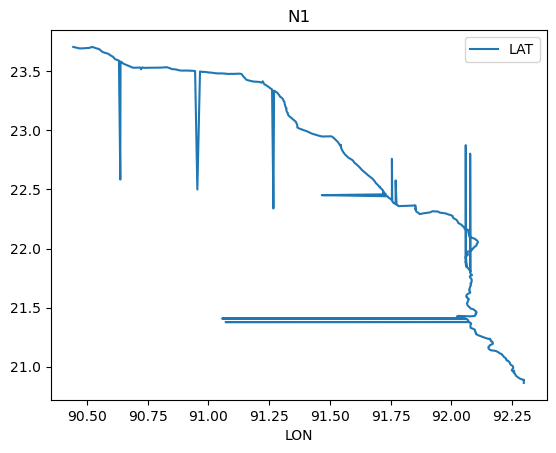

In [30]:
df_rd1.plot(x="LON", y="LAT", title="N1")

In [31]:
df_rd1.describe()

,LAT,LON
count,1348.000000,1348.000000
mean,22.210546,91.738093
std,0.895552,0.506570
min,20.862917,90.443333
25%,21.383632,91.374687
50%,22.212375,92.027652
75%,22.997764,92.094923
max,23.706083,92.299639


In [32]:
dist_dict = {}
# for index, data in df_rd1.iterrows():
#     print(index)
#     print(f"LRP: {data['LRP']}, LAT: {data['LAT']}, LON: {data['LON']}")
#     dist_dict[(data['LRP'],)]

for i in range(0, len(df_rd1) - 1, 1):
    point1 = df_rd1.iloc[i]
    point2 = df_rd1.iloc[i+1]
    coord1 = (point1.LAT, point1.LON)
    coord2 = (point2.LAT, point2.LON)
    distance = dist(coord1, coord2)
    dist_dict[(point1.LRP, point2.LRP)] = distance

print(dist_dict)    


{('LRPS', 'LRPSa'): 0.007736778974492407, ('LRPSa', 'LRPSb'): 0.00014957760526745724, ('LRPSb', 'LRP001'): 0.0016303966419322746, ('LRP001', 'LRP002'): 0.009602921081626777, ('LRP002', 'LRP002a'): 0.0012051258855397366, ('LRP002a', 'LRP003'): 0.008262486616636817, ('LRP003', 'LRP004'): 0.00964146078402946, ('LRP004', 'LRP004a'): 0.001760764424903285, ('LRP004a', 'LRP005'): 0.00802835169944827, ('LRP005', 'LRP006'): 0.00976434057783821, ('LRP006', 'LRP007'): 0.009660344905846165, ('LRP007', 'LRP007a'): 0.001635362874109137, ('LRP007a', 'LRP008'): 0.007659249039554635, ('LRP008', 'LRP008a'): 7.855959520890134e-05, ('LRP008a', 'LRP008b'): 0.003929909267409732, ('LRP008b', 'LRP009'): 0.0006690143869923468, ('LRP009', 'LRP009a'): 0.002435050638071047, ('LRP009a', 'LRP010'): 0.006855222349426807, ('LRP010', 'LRP010a'): 0.0012841305852534207, ('LRP010a', 'LRP010b'): 0.0030279798282112688, ('LRP010b', 'LRP010c'): 0.00391324595316821, ('LRP010c', 'LRP011'): 0.0012888716499216259, ('LRP011', 'LR

In [33]:
median_n1 = np.median(list(dist_dict.values()))

In [34]:
std_n1 = np.std(list(dist_dict.values()))
std_n1

0.10288286894080224

In [35]:
outliers = []
for (LRP1, LRP2), distance in dist_dict.items():
    if distance > median_n1 + 1 * std_n1:
        outliers.append((LRP1, LRP2, distance))
print(len(outliers))
print("Outliers:", outliers)

20
Outliers: [('LRP027', 'LRP027a', 1.0058764439621901), ('LRP027a', 'LRP028', 0.9990834464494218), ('LRP064', 'LRP065', 1.0025433332977522), ('LRP065', 'LRP066', 0.999171141425133), ('LRP107', 'LRP108', 1.0073207640722974), ('LRP108', 'LRP108a', 0.9969762259761898), ('LRP224b', 'LRP225', 0.26394753651643293), ('LRP225', 'LRP226', 0.26993819515454653), ('LRP230b', 'LRP230c', 0.3500000000000014), ('LRP230c', 'LRP231', 0.35519721546411687), ('LRP234a', 'LRP234b', 0.19986113087946808), ('LRP234b', 'LRP235', 0.20719914642145465), ('LRP323', 'LRP323a', 0.9955000003881666), ('LRP324', 'LRP324a', 1.0079993646792125), ('LRP331c', 'LRP332', 0.999888900000002), ('LRP332', 'LRP333', 1.0087232119337666), ('LRP391', 'LRP391a', 0.9987506180439701), ('LRP391a', 'LRP391b', 1.0010563804258787), ('LRP395a', 'LRP395b', 0.9999731888686677), ('LRP395b', 'LRP395c', 1.0002500189104055)]


In [36]:
lrp_outliers = []
for i in range(0, len(outliers), 2):
    lrp1, lrp2, dist = outliers[i]
    lrp2_2, lrp3, dist2 = outliers[i+1]
    if lrp2 == lrp2_2:
        print(f'De outlier is {lrp2}')
        lrp_outliers.append(lrp2)
    else:
        if abs(dist - dist2) < 0.5 * std_n1:
            print(f'De outlier is {lrp2} maar ook {lrp2_2} is een outlier')
            lrp_outliers.append(lrp2)
            lrp_outliers.append(lrp2_2)

De outlier is LRP027a
De outlier is LRP065
De outlier is LRP108
De outlier is LRP225
De outlier is LRP230c
De outlier is LRP234b
De outlier is LRP323a maar ook LRP324 is een outlier
De outlier is LRP332
De outlier is LRP391a
De outlier is LRP395b


In [37]:
# lrp_outliers
df_rd1_outliers = df_rd1[df_rd1["LRP"].isin(lrp_outliers)]
df_rd1_outliers

,road,LRP,LAT,LON
69,N1,LRP027a,22.583750,90.636944
154,N1,LRP065,22.499527,90.954167
233,N1,LRP108,22.339055,91.267222
538,N1,LRP225,22.451861,91.466611
553,N1,LRP230c,22.758417,91.755139
567,N1,LRP234b,22.576333,91.770527
792,N1,LRP323a,22.874916,92.059111
793,N1,LRP324,22.870499,92.059139
817,N1,LRP332,22.802917,92.077277
993,N1,LRP391a,21.407972,91.056000


In [38]:
def snap_point(lrp, index):
    prev_pt = df_rd1.iloc[index - 1]
    next_pt = df_rd1.iloc[index + 1]
    curr_pt = df_rd1.iloc[index]

    if prev_pt['LRP'] in lrp_outliers:
        prev_pt = df_rd1.iloc[index - 2] 
    if next_pt['LRP'] in lrp_outliers:
        next_pt = df_rd1.iloc[index + 2] 
        

    exp_lat = (prev_pt['LAT'] + next_pt['LAT']) / 2.0
    exp_lon = (prev_pt['LON'] + next_pt['LON']) / 2.0

    # 4. Calculate Deviations (How far off is the current point?)
    # We use absolute difference
    lat_diff = abs(curr_pt['LAT'] - exp_lat)
    lon_diff = abs(curr_pt['LON'] - exp_lon)

    if lat_diff > lon_diff:
        print(f"Snapping Index {index} along Y-axis (Fixing Latitude)")
        df_rd1_copy.at[index, 'LAT'] = exp_lat  # Snap Lat to the trend line
        # Lon remains untouched (df.at[index, 'lon'] is not changed)
        
    else:
        # Otherwise -> Trust Lat, Fix Lon
        print(f"Snapping Index {index} along X-axis (Fixing Longitude)")
        df_rd1_copy.at[index, 'LON'] = exp_lon  # Snap Lon to the trend line
        # Lat remains untouched

df_rd1_copy = df_rd1.copy()

for outlier in lrp_outliers:
    index = np.where(df_rd1['LRP'] == outlier)[0]
    # print(f"LRP {outlier} is found at index {index[0]}")
    snap_point(outlier, index[0])

# df_rd1_copy.plot(x="LON", y="LAT", title="N1 Snapped")




Snapping Index 69 along Y-axis (Fixing Latitude)
Snapping Index 154 along Y-axis (Fixing Latitude)
Snapping Index 233 along Y-axis (Fixing Latitude)
Snapping Index 538 along X-axis (Fixing Longitude)
Snapping Index 553 along Y-axis (Fixing Latitude)
Snapping Index 567 along Y-axis (Fixing Latitude)
Snapping Index 792 along Y-axis (Fixing Latitude)
Snapping Index 793 along Y-axis (Fixing Latitude)
Snapping Index 817 along Y-axis (Fixing Latitude)
Snapping Index 993 along X-axis (Fixing Longitude)
Snapping Index 1016 along X-axis (Fixing Longitude)


Text(0.5, 1.0, 'Snapped N1')

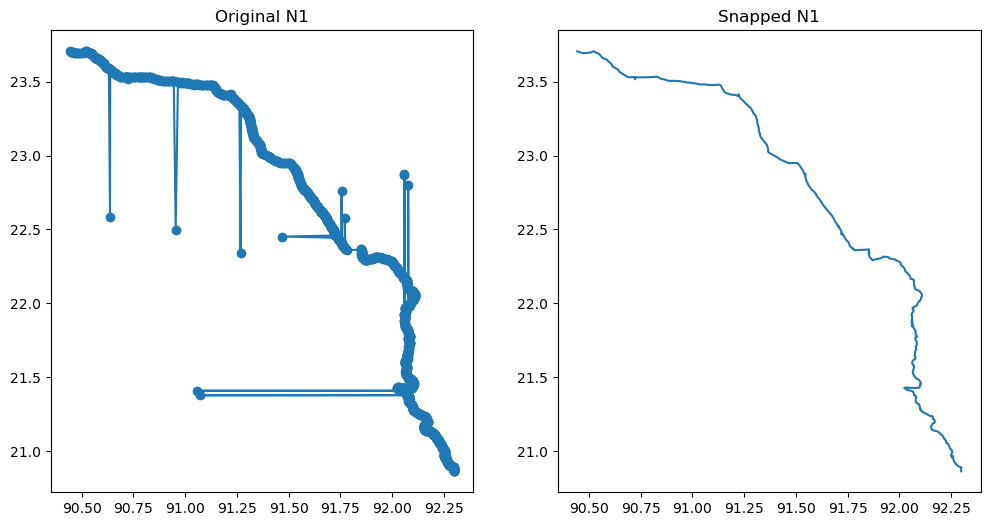

In [39]:
f, axes = plt.subplots(1,2, figsize=(12, 6))
axes.flatten()
axes[0].plot(df_rd1['LON'], df_rd1['LAT'], marker='o', label='Original N1')
axes[0].set_title('Original N1')
axes[1].plot(df_rd1_copy['LON'], df_rd1_copy['LAT'],  label='Snapped N1')
axes[1].set_title('Snapped N1')
